## Install Packages

In [1]:
import sys, site, platform
print("Python:", sys.version)
print("Executable:", sys.executable)
print("Platform:", platform.platform())
print("Site-packages:", site.getsitepackages() if hasattr(site, "getsitepackages") else "n/a")


Python: 3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]
Executable: /home/ubuntu/venv/bin/python
Platform: Linux-6.14.0-1018-aws-x86_64-with-glibc2.39
Site-packages: ['/home/ubuntu/venv/lib/python3.12/site-packages', '/home/ubuntu/venv/local/lib/python3.12/dist-packages', '/home/ubuntu/venv/lib/python3/dist-packages', '/home/ubuntu/venv/lib/python3.12/dist-packages']


In [2]:
!python -V
!pip show torch transformers pyarrow

Python 3.12.3


Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /home/ubuntu/venv/lib/python3.12/site-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: torchaudio, torchvision
---
Name: transformers
Version: 4.57.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/co

In [3]:
!pip install pandas matplotlib tqdm pyarrow transformers gdown ujson

In [4]:
!python -m pip install -U pip setuptools wheel
!pip --version


pip 25.3 from /home/ubuntu/venv/lib/python3.12/site-packages/pip (python 3.12)


In [5]:
!nvidia-smi


Thu Jan 15 23:40:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:31:00.0 Off |                    0 |
| N/A   37C    P0             29W /   72W |       0MiB /  23034MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124


Looking in indexes: https://download.pytorch.org/whl/cu124


In [7]:
!pip install pandas matplotlib tqdm transformers gdown ujson

In [8]:
!pip install pyarrow

In [9]:
import torch
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


/home/ubuntu/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA L4


In [10]:
import os, json
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

## Load TWeddit

In [11]:
DATA_PATH = "../datasets/5000_Posts_Annotations - Combined_Dataset.csv"  # <-- change me

df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head(2)

Rows: 4994
Columns: ['id', 'subreddit', 'title', 'body', 'Tags', 'Unnamed: 5']


,id,subreddit,title,body,Tags,Unnamed: 5
0,1ljxynj,abortion,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Medical, Pregnancy, Mental Health",NaN
1,1ljxtt8,abortion,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,"Medical, Pregnancy, Mental Health",NaN


In [12]:
TITLE_COL = "title"
BODY_COL  = "body"

def build_text(row):
    t = str(row.get(TITLE_COL, "")).strip()
    b = str(row.get(BODY_COL, "")).strip()
    if t and b:
        return f"{t}\n\n{b}"
    return t or b

df["text"] = df.apply(build_text, axis=1)

# Create an ID column if you don't have one
ID_COL = "post_id" if "post_id" in df.columns else None
if ID_COL is None:
    df["post_id"] = np.arange(len(df))
    ID_COL = "post_id"

df[[ID_COL, "text"]].head(3)


,post_id,text
0,0,"Complications after abortion?\n\nHi everyone, ..."
1,1,Second MA abortion today and I'm absolutely te...
2,2,Help needed/ live in Texas where abortion in b...


In [13]:
# If you already have created_utc:
if "created_utc" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_utc"], unit="s", utc=True).dt.tz_convert(None)
elif "created_dt" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_dt"])
else:
    df["created_dt"] = pd.NaT  # timeline plots will be skipped unless you fill this


## DAMF

In [14]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using DEVICE:", DEVICE)


Using DEVICE: cuda


In [15]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MF_MODEL_NAME = "MMADS/MoralFoundationsClassifier"  # :contentReference[oaicite:2]{index=2}
mf_tokenizer = AutoTokenizer.from_pretrained(MF_MODEL_NAME)
mf_model = AutoModelForSequenceClassification.from_pretrained(MF_MODEL_NAME).to(DEVICE)
mf_model.eval()

# Label names (virtue/vice pairs) per model card :contentReference[oaicite:3]{index=3}
mf_src_labels = [
    "care_virtue",
    "care_vice",
    "fairness_virtue",
    "fairness_vice",
    "loyalty_virtue",
    "loyalty_vice",
    "authority_virtue",
    "authority_vice",
    "sanctity_virtue",
    "sanctity_vice",
]

# Map to DAMF-style 10 labels
mf_to_damf = {
    "care_virtue": "care",
    "care_vice": "harm",
    "fairness_virtue": "fairness",
    "fairness_vice": "cheating",
    "loyalty_virtue": "loyalty",
    "loyalty_vice": "betrayal",
    "authority_virtue": "authority",
    "authority_vice": "subversion",
    "sanctity_virtue": "purity",
    "sanctity_vice": "degradation",
}
damf_labels = list(mf_to_damf.values())
damf_labels


['care',
 'harm',
 'fairness',
 'cheating',
 'loyalty',
 'betrayal',
 'authority',
 'subversion',
 'purity',
 'degradation']

In [16]:
@torch.no_grad()
def mf_predict_proba(texts, batch_size=16, max_length=256):
    probs_all = []
    for i in tqdm(range(0, len(texts), batch_size), desc="MF batches"):
        batch = texts[i:i+batch_size]
        enc = mf_tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(DEVICE)

        logits = mf_model(**enc).logits
        probs = torch.sigmoid(logits).cpu().numpy()  # (bs, 10)
        probs_all.append(probs)

    return np.vstack(probs_all)

mf_probs = mf_predict_proba(df["text"].tolist(), batch_size=16, max_length=256)
mf_probs.shape


MF batches: 100%|██████████| 313/313 [00:31<00:00, 10.06it/s]


(4994, 10)

In [17]:
# Add source columns
for j, lab in enumerate(mf_src_labels):
    df[f"mf_{lab}_p"] = mf_probs[:, j]

# Convert to DAMF-style 10 columns
for src_lab, damf_lab in mf_to_damf.items():
    df[f"damf_{damf_lab}_p"] = df[f"mf_{src_lab}_p"]

# Threshold (tune this!)
MF_THRESHOLD = 0.50
for damf_lab in damf_labels:
    df[f"damf_{damf_lab}"] = (df[f"damf_{damf_lab}_p"] >= MF_THRESHOLD).astype(int)

df[[ID_COL] + [f"damf_{x}_p" for x in damf_labels]].head(3)


,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,0.005915
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,0.007386
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,0.001553


In [18]:
if df["created_dt"].notna().any():
    tmp = df.dropna(subset=["created_dt"]).copy()
    tmp["date"] = tmp["created_dt"].dt.date

    series = tmp.groupby("date")[[f"damf_{x}_p" for x in damf_labels]].mean()

    plt.figure()
    for col in series.columns:
        plt.plot(series.index, series[col], label=col.replace("damf_", "").replace("_p",""))
    plt.xticks(rotation=45)
    plt.title("Moral Foundations over time (mean probability)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No created_dt available — skipping timeline plot.")


No created_dt available — skipping timeline plot.


In [19]:
MF_THRESHOLD = 0.50  # try 0.30 / 0.40 / 0.50 and see what feels right

damf_labels = [
    "care","harm","fairness","cheating","loyalty",
    "betrayal","authority","subversion","purity","degradation"
]

for lab in damf_labels:
    pcol = f"damf_{lab}_p"
    outcol = f"damf_{lab}"
    df[outcol] = (df[pcol] >= MF_THRESHOLD).astype(int)

# quick peek
show_cols = ["post_id"] + [f"damf_{x}_p" for x in damf_labels] + [f"damf_{x}" for x in damf_labels]
df[show_cols].head(3)

,post_id,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,...,damf_care,damf_harm,damf_fairness,damf_cheating,damf_loyalty,damf_betrayal,damf_authority,damf_subversion,damf_purity,damf_degradation
0,0,0.003438,0.966401,0.001048,0.002625,0.002817,0.002294,0.008466,0.001026,0.003422,...,0,1,0,0,0,0,0,0,0,0
1,1,0.002046,0.938751,0.001945,0.006581,0.002041,0.006259,0.010394,0.015026,0.002759,...,0,1,0,0,0,0,0,0,0,0
2,2,0.988506,0.003383,0.001098,0.000688,0.002149,0.000553,0.004982,0.000816,0.002226,...,1,0,0,0,0,0,0,0,0,0


In [20]:
pcols = [f"damf_{x}_p" for x in damf_labels]

df["damf_top_label"] = df[pcols].idxmax(axis=1).str.replace("damf_", "", regex=False).str.replace("_p", "", regex=False)
df["damf_top_p"] = df[pcols].max(axis=1)

df[["post_id", "damf_top_label", "damf_top_p"]].head(10)

,post_id,damf_top_label,damf_top_p
0,0,harm,0.966401
1,1,harm,0.938751
2,2,care,0.988506
3,3,purity,0.989918
4,4,care,0.954838
5,5,care,0.912512
6,6,care,0.944189
7,7,harm,0.987779
8,8,authority,0.991221
9,9,care,0.945758


In [21]:
top_dist = df["damf_top_label"].value_counts(dropna=False).to_frame("count")
top_dist["percent"] = (top_dist["count"] / len(df) * 100).round(2)
top_dist


,count,percent
damf_top_label,,
care,1663,33.30
harm,1215,24.33
authority,687,13.76
loyalty,659,13.20
purity,338,6.77
degradation,294,5.89
fairness,93,1.86
cheating,35,0.70
subversion,9,0.18


In [22]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
mean_probs = df[[f"damf_{x}_p" for x in damf_labels]].mean().sort_values(ascending=False)
mean_probs


damf_care_p           0.508902
damf_harm_p           0.393973
damf_loyalty_p        0.247445
damf_degradation_p    0.244180
damf_purity_p         0.188721
damf_authority_p      0.170709
damf_fairness_p       0.079946
damf_cheating_p       0.045310
damf_subversion_p     0.016149
damf_betrayal_p       0.009547
dtype: float32

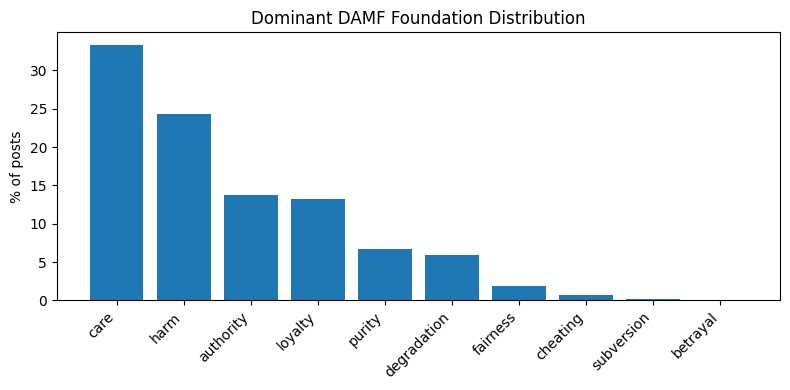

In [23]:
import matplotlib.pyplot as plt

td = (
    top_dist
    .reset_index()
    .rename(columns={"index": "damf_top_label"})
    .sort_values("count", ascending=False)
)

plt.figure(figsize=(8,4))
plt.bar(td["damf_top_label"], td["percent"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("% of posts")
plt.title("Dominant DAMF Foundation Distribution")
plt.tight_layout()
plt.show()


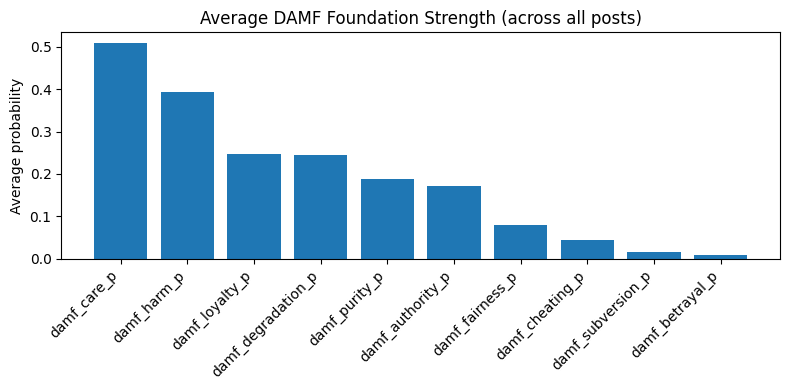

In [24]:
import matplotlib.pyplot as plt

mp = mean_probs.sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(mp.index, mp.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average probability")
plt.title("Average DAMF Foundation Strength (across all posts)")
plt.tight_layout()
plt.show()


In [25]:
bin_cols = [f"damf_{x}" for x in damf_labels if f"damf_{x}" in df.columns]
if bin_cols:
    (df[bin_cols].mean().sort_values(ascending=False) * 100).round(2)
else:
    print("No binary columns found. Run the thresholding cell first.")


In [26]:
[c for c in df.columns if "utc" in c.lower() or "date" in c.lower() or "time" in c.lower() or "created" in c.lower()]

['created_dt']

In [27]:
import json
import pandas as pd

ID_COL = "id"          # you have "id", not "post_id"
TAGS_COL = "Tags"      # your tags are here

TW_LABELS = ["Medical","Mental Health","Abuse","Aggression","Sexual","Discrimination","Pregnancy","Not Applicable"]

def parse_tags(x):
    """
    Robust parsing for Tags column.
    Handles:
      - JSON-like lists: ["Medical","Abuse"]
      - Python-like lists as strings: ['Medical', 'Abuse']
      - separators: ; , |
      - single label string
      - empty/NaN
    """
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return [str(t).strip() for t in x if str(t).strip()]

    s = str(x).strip()
    if not s:
        return []

    # JSON-ish list
    if s.startswith("[") and s.endswith("]"):
        try:
            arr = json.loads(s.replace("'", '"'))
            if isinstance(arr, list):
                return [str(t).strip() for t in arr if str(t).strip()]
        except Exception:
            pass

    # split by common separators
    for sep in [";", "|", ","]:
        if sep in s:
            return [t.strip() for t in s.split(sep) if t.strip()]

    return [s]

parsed = df[TAGS_COL].apply(parse_tags)

for lab in TW_LABELS:
    df[lab] = parsed.apply(lambda lst: int(lab in lst))

# quick check: how many posts per label
df[TW_LABELS].sum().sort_values(ascending=False)


Mental Health     3550
Pregnancy         2652
Medical           1815
Abuse             1703
Sexual             918
Not Applicable     862
Discrimination     526
Aggression         196
dtype: int64

In [28]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
damf_pcols = [f"damf_{x}_p" for x in damf_labels]

tw_present = [c for c in TW_LABELS if c in df.columns]
print("TW labels found:", tw_present)

rows = []
for lab in tw_present:
    sub = df[df[lab] == 1]
    if len(sub) == 0:
        continue
    row = {"tw_label": lab, "n": len(sub)}
    row.update(sub[damf_pcols].mean().to_dict())
    rows.append(row)

if not rows:
    print("No TW rows found (either Tags empty or labels not matching).")
else:
    tw_moral = pd.DataFrame(rows).sort_values("n", ascending=False)
    display(tw_moral)


TW labels found: ['Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable']


,tw_label,n,damf_care_p,damf_harm_p,damf_fairness_p,damf_cheating_p,damf_loyalty_p,damf_betrayal_p,damf_authority_p,damf_subversion_p,damf_purity_p,damf_degradation_p
1,Mental Health,3550,0.519977,0.433386,0.078629,0.041701,0.244758,0.008927,0.166078,0.013912,0.189742,0.262438
6,Pregnancy,2652,0.529277,0.270035,0.061415,0.030773,0.203995,0.007085,0.139380,0.014520,0.249452,0.110133
0,Medical,1815,0.479672,0.275630,0.041363,0.023557,0.145429,0.006198,0.116846,0.014301,0.281709,0.107614
2,Abuse,1703,0.493780,0.642513,0.102571,0.060852,0.303743,0.012348,0.227194,0.015407,0.104930,0.465759
4,Sexual,918,0.473682,0.591145,0.080210,0.045435,0.266367,0.009278,0.194762,0.013115,0.110064,0.442628
7,Not Applicable,862,0.535679,0.296316,0.106799,0.078483,0.335187,0.014344,0.210246,0.026567,0.189105,0.217078
5,Discrimination,526,0.618736,0.496586,0.155526,0.057241,0.329699,0.013480,0.298929,0.023343,0.183261,0.360441
3,Aggression,196,0.530235,0.698316,0.101225,0.079597,0.321115,0.013482,0.307395,0.016458,0.132826,0.402455


In [29]:
damf_labels = ["care","harm","fairness","cheating","loyalty","betrayal","authority","subversion","purity","degradation"]
pcols = [f"damf_{x}_p" for x in damf_labels]

tw_moral2 = tw_moral.copy()

def topk_row(row, k=3):
    vals = row[pcols].sort_values(ascending=False).head(k)
    return ", ".join([f"{c.replace('damf_','').replace('_p','')}={v:.3f}" for c, v in vals.items()])

tw_moral2["top3_moral"] = tw_moral2.apply(topk_row, axis=1)
tw_moral2[["tw_label","n","top3_moral"]]


,tw_label,n,top3_moral
1,Mental Health,3550,"care=0.520, harm=0.433, degradation=0.262"
6,Pregnancy,2652,"care=0.529, harm=0.270, purity=0.249"
0,Medical,1815,"care=0.480, purity=0.282, harm=0.276"
2,Abuse,1703,"harm=0.643, care=0.494, degradation=0.466"
4,Sexual,918,"harm=0.591, care=0.474, degradation=0.443"
7,Not Applicable,862,"care=0.536, loyalty=0.335, harm=0.296"
5,Discrimination,526,"care=0.619, harm=0.497, degradation=0.360"
3,Aggression,196,"harm=0.698, care=0.530, degradation=0.402"


In [30]:
baseline_label = "Not Applicable"
base = tw_moral[tw_moral["tw_label"] == baseline_label].iloc[0]

delta_rows = []
for _, row in tw_moral.iterrows():
    lab = row["tw_label"]
    if lab == baseline_label:
        continue
    d = {"tw_label": lab, "n": int(row["n"])}
    for c in pcols:
        d[c.replace("_p","_delta_vs_NA")] = row[c] - base[c]
    delta_rows.append(d)

tw_delta = pd.DataFrame(delta_rows)

# show biggest positive deltas in harm & degradation (often interesting for TW)
tw_delta[["tw_label","n","damf_harm_delta_vs_NA","damf_degradation_delta_vs_NA","damf_care_delta_vs_NA"]].sort_values(
    "damf_harm_delta_vs_NA", ascending=False
)


,tw_label,n,damf_harm_delta_vs_NA,damf_degradation_delta_vs_NA,damf_care_delta_vs_NA
6,Aggression,196,0.402000,0.185377,-0.005443
3,Abuse,1703,0.346198,0.248681,-0.041899
4,Sexual,918,0.294829,0.225550,-0.061997
5,Discrimination,526,0.200271,0.143363,0.083057
0,Mental Health,3550,0.137071,0.045360,-0.015702
2,Medical,1815,-0.020686,-0.109464,-0.056007
1,Pregnancy,2652,-0.026280,-0.106945,-0.006401


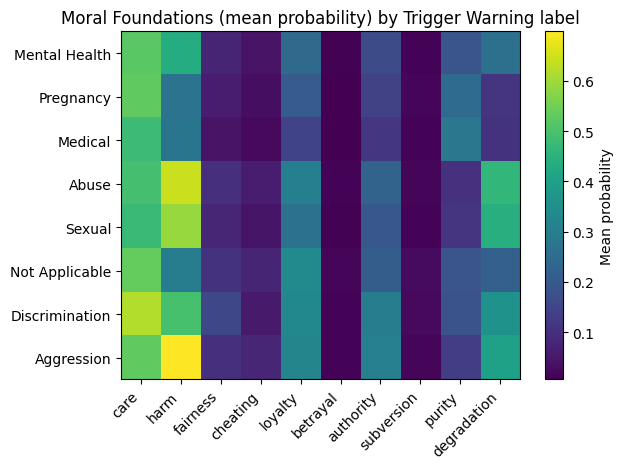

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Order labels by n (already sorted in your screenshot, but ensure)
plot_df = tw_moral.sort_values("n", ascending=False).copy()

M = plot_df[pcols].to_numpy()
labels_y = plot_df["tw_label"].tolist()
labels_x = [c.replace("damf_","").replace("_p","") for c in pcols]

plt.figure()
plt.imshow(M, aspect="auto")
plt.xticks(range(len(labels_x)), labels_x, rotation=45, ha="right")
plt.yticks(range(len(labels_y)), labels_y)
plt.colorbar(label="Mean probability")
plt.title("Moral Foundations (mean probability) by Trigger Warning label")
plt.tight_layout()
plt.show()


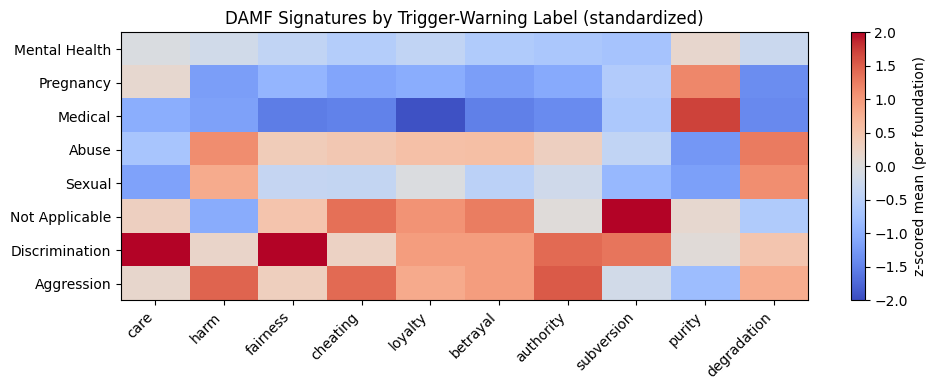

In [32]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = tw_moral.sort_values("n", ascending=False).copy()
M = plot_df[pcols].to_numpy()

# z-score by column (foundation)
M_z = (M - M.mean(axis=0, keepdims=True)) / (M.std(axis=0, keepdims=True) + 1e-9)

labels_y = plot_df["tw_label"].tolist()
labels_x = [c.replace("damf_","").replace("_p","") for c in pcols]

plt.figure(figsize=(10,4))
im = plt.imshow(M_z, aspect="auto", vmin=-2, vmax=2, cmap="coolwarm")  # centered at 0
plt.xticks(range(len(labels_x)), labels_x, rotation=45, ha="right")
plt.yticks(range(len(labels_y)), labels_y)

plt.colorbar(im, label="z-scored mean (per foundation)")
plt.title("DAMF Signatures by Trigger-Warning Label (standardized)")
plt.tight_layout()
plt.show()


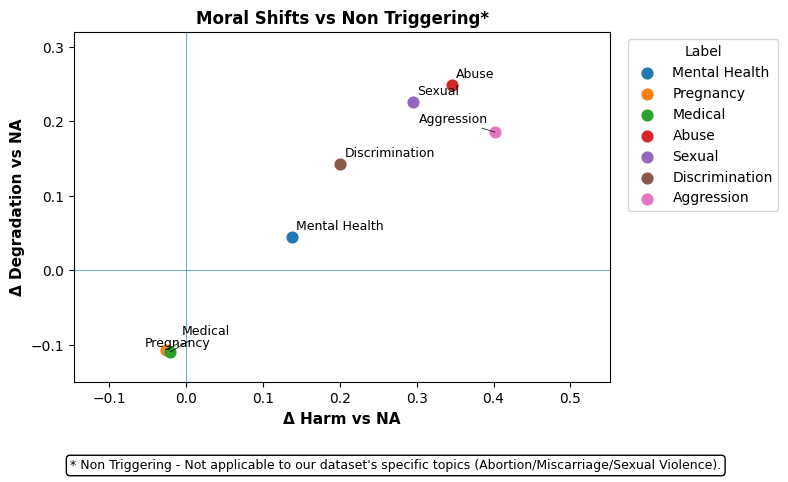

In [48]:
plt.figure(figsize=(8,5))

labels = tw_delta["tw_label"].unique()
cmap = plt.get_cmap("tab10")
color_map = {lab: cmap(i % 10) for i, lab in enumerate(labels)}

# Scatter points
for lab in labels:
    d = tw_delta[tw_delta["tw_label"] == lab]
    plt.scatter(
        d["damf_harm_delta_vs_NA"],
        d["damf_degradation_delta_vs_NA"],
        label=lab,
        color=color_map[lab],
        s=60
    )

# Annotation offsets to avoid overlap
offsets = {
    "Pregnancy": (-15, 0),
    "Medical": (8, 10),
    "Aggression": (-55, 5),
}

for _, r in tw_delta.iterrows():
    x = r["damf_harm_delta_vs_NA"]
    y = r["damf_degradation_delta_vs_NA"]
    lab = r["tw_label"]

    dx, dy = offsets.get(lab, (3, 3))
    plt.annotate(
        lab,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        ha="left",
        va="bottom",
        arrowprops=dict(
            arrowstyle="-",
            lw=0.5,
            shrinkA=0,
            shrinkB=0
        ) if lab in offsets else None,
        clip_on=False
    )

# Zero reference lines (ICWSM-style: subtle)
plt.axhline(0, linewidth=0.8, alpha=0.6)
plt.axvline(0, linewidth=0.8, alpha=0.6)

# ICWSM-style axis limits (extra breathing room)
xmin = tw_delta["damf_harm_delta_vs_NA"].min()
xmax = tw_delta["damf_harm_delta_vs_NA"].max()
plt.xlim(xmin - 0.12, xmax + 0.15)
plt.ylim(-0.15, 0.32)

# Axis labels (bold, readable at single-column width)
plt.xlabel("Δ Harm vs NA", fontsize=11, fontweight="bold")
plt.ylabel("Δ Degradation vs NA", fontsize=11, fontweight="bold")

# Title (slightly smaller than axes labels, ICWSM convention)
plt.title("Moral Shifts vs Non Triggering*", fontsize=12, fontweight="bold", loc = "center")

# Legend
plt.legend(title="Label", bbox_to_anchor=(1.02, 1), loc="upper left")

# Explanatory footnote box (clearly separated from plot)
plt.text(
    0.6, -0.22,
    "* Non Triggering - Not applicable to our dataset's specific topics (Abortion/Miscarriage/Sexual Violence).",
    ha="center",
    va="top",
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
)

# Layout + export (ICWSM / LaTeX safe)
plt.tight_layout()
plt.savefig(
    "moral_shifts_vs_out_of_scope_icwsm.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


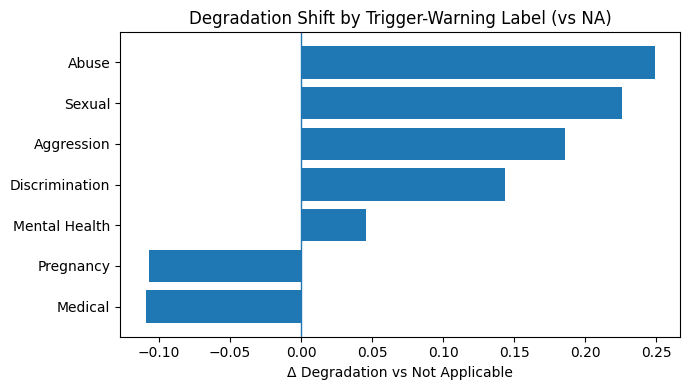

In [34]:
d = tw_delta.sort_values("damf_degradation_delta_vs_NA", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(d["tw_label"], d["damf_degradation_delta_vs_NA"])
plt.axvline(0, linewidth=1)
plt.xlabel("Δ Degradation vs Not Applicable")
plt.title("Degradation Shift by Trigger-Warning Label (vs NA)")
plt.tight_layout()
plt.show()
